# GRB clustering

Discover clustering methods and conclude with some observation about Gamma-Ray-Bust.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report

In [4]:
load = np.loadtxt("Summary_GRB.txt", dtype='str',unpack='True')

### Warm up

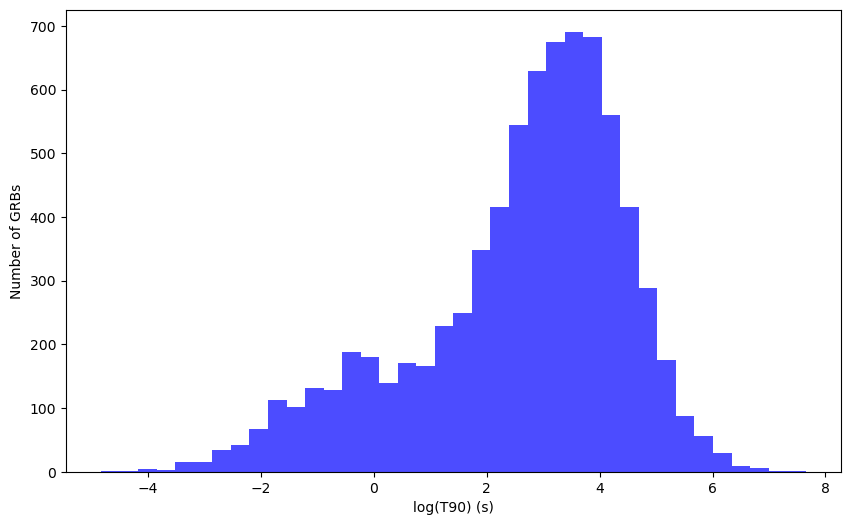

In [31]:
T90 = np.array(load[6], dtype=float)
mask = (T90 > 0)
T90 = T90[mask]

plt.figure(figsize=(10, 6))
plt.hist(np.log(T90), bins='scott', color='blue', alpha=0.7)
plt.xlabel('log(T90) (s)')
plt.ylabel('Number of GRBs')
plt.show()

In [6]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |  
 |  K-Means clustering.
 |  
 |  Read more in the :ref:`User Guide <k_means>`.
 |  
 |  Parameters
 |  ----------
 |  
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |  
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |  
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |  
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to t

Preprocessig is needed to make work the distance that minimize in the loss function of K-mean.

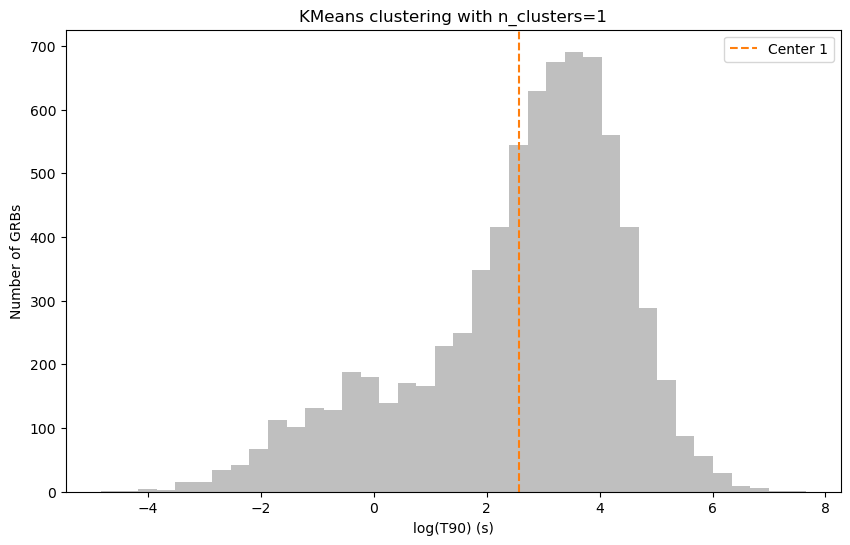

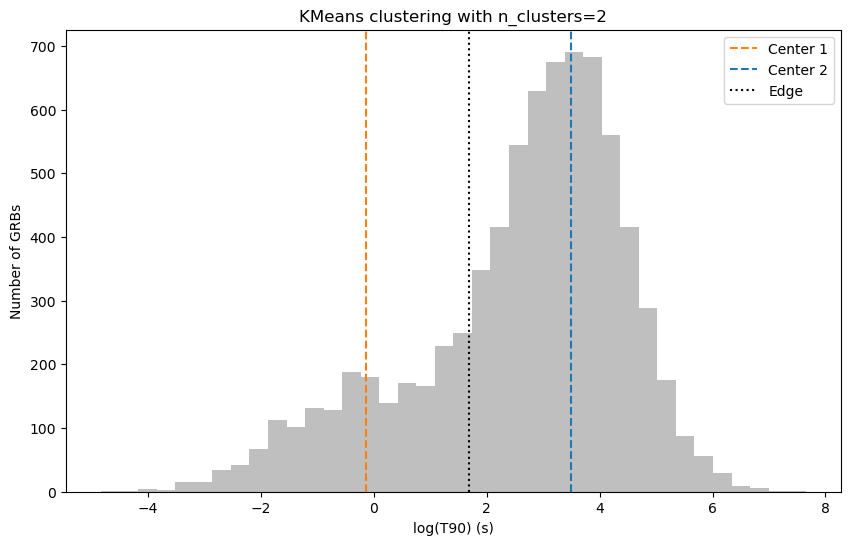

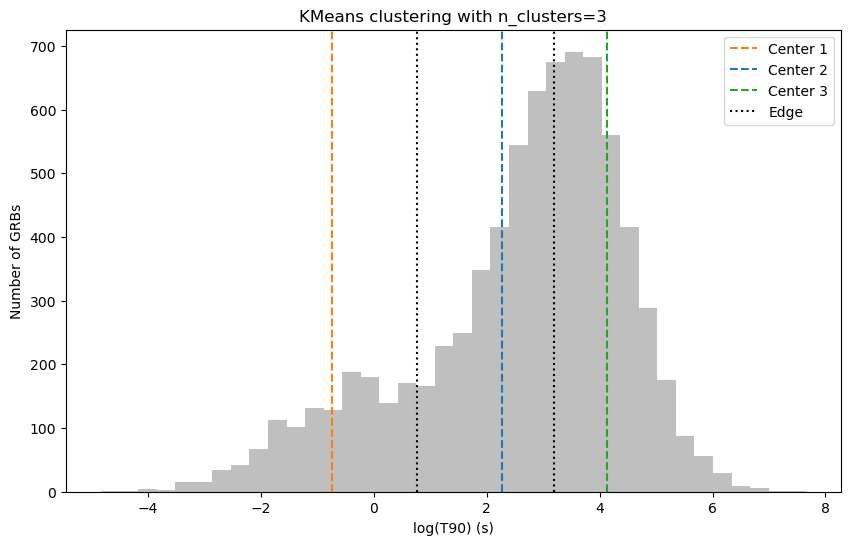

In [35]:
scaler = preprocessing.StandardScaler()

X = np.log(T90).reshape(-1, 1)
X = scaler.fit_transform(X)
colors = ['C1', 'C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

for n in range(1, 4):
    clKM = KMeans(n_clusters=n, random_state=1234, n_init='auto')
    labels = clKM.fit_predict(X)
    centers = scaler.inverse_transform(clKM.cluster_centers_).ravel()
    centers = np.sort(centers)

    plt.figure(figsize=(10, 6))
    plt.hist(scaler.inverse_transform(X), bins='scott', color='gray', alpha=0.5)
    for i in enumerate(centers):
        plt.axvline(x=i[1], color=colors[i[0]], linestyle='--', label=f'Center {i[0]+1}')
    if n > 1:
        edges = (centers[:-1] + centers[1:]) / 2
        for edge_idx, edge in enumerate(edges):
            plt.axvline(x=edge, color='black', linestyle=':', linewidth=1.5, label='Edge' if edge_idx == 0 else None)

    plt.xlabel('log(T90) (s)')
    plt.ylabel('Number of GRBs')
    plt.title(f'KMeans clustering with n_clusters={n}')
    plt.legend()
    plt.show()

### More features

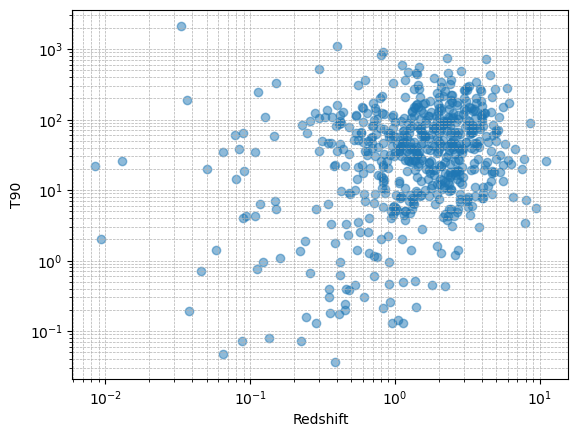

In [8]:
redshift = np.array(load[11], dtype=float)
T90 = np.array(load[6], dtype=float)

mask = (redshift > 0) & (T90 > 0)

plt.scatter(redshift[mask], T90[mask], alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [9]:
nclusters = 5
data = np.column_stack((redshift[mask], T90[mask]))
data_scaled = scaler.fit_transform(data)

In [10]:
clKM = KMeans(n_clusters=nclusters, n_init='auto')
clKM.fit(data_scaled)

KMeans(n_clusters=5)

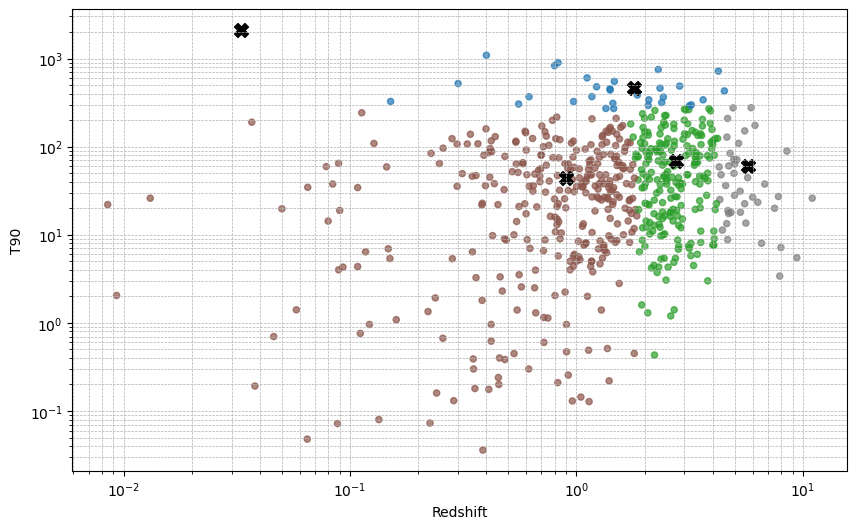

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
plt.scatter(scaler.inverse_transform(clKM.cluster_centers_)[:, 0], scaler.inverse_transform(clKM.cluster_centers_)[:, 1], c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)


In [12]:
clMS = MeanShift(bandwidth=1.0)
clMS.fit(data_scaled)

MeanShift(bandwidth=1.0)

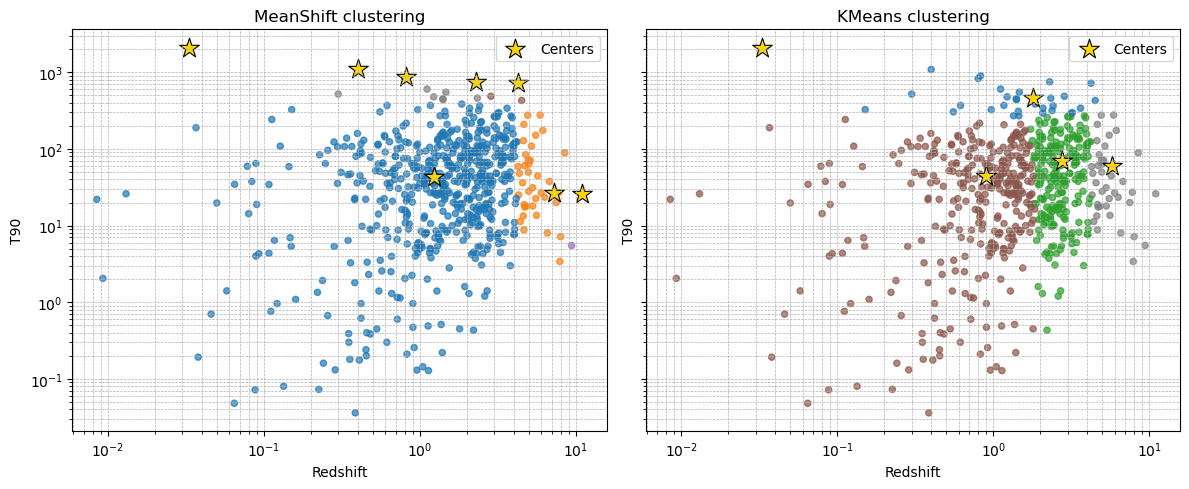

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=clMS.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = scaler.inverse_transform(clKM.cluster_centers_)
centersMS = scaler.inverse_transform(clMS.cluster_centers_)

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**

- It's an unsupervised learning: we are sensible on number of cluster wich we can fix with cross validation. Comparison beetween the two method is difficult because of different loss function; there are still method probabily in the licterature.

- MeanShift is very sensible to bandwith input.

- When we have a single point cluster could we interprete this as outliers?

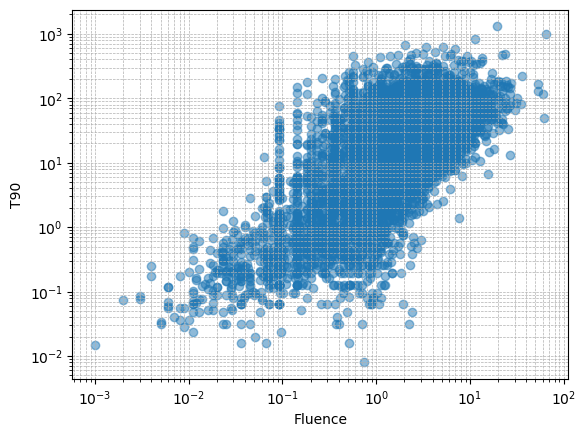

In [14]:
fluence = np.array(load[7], dtype=float)

mask = (fluence > 0) & (T90 > 0)
data = np.column_stack((fluence[mask], T90[mask]))

data_scaled = scaler.fit_transform(data)

plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title('')
plt.xlabel('Fluence')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [15]:
nclusters = 3
clKM = KMeans(n_clusters=nclusters, n_init='auto')

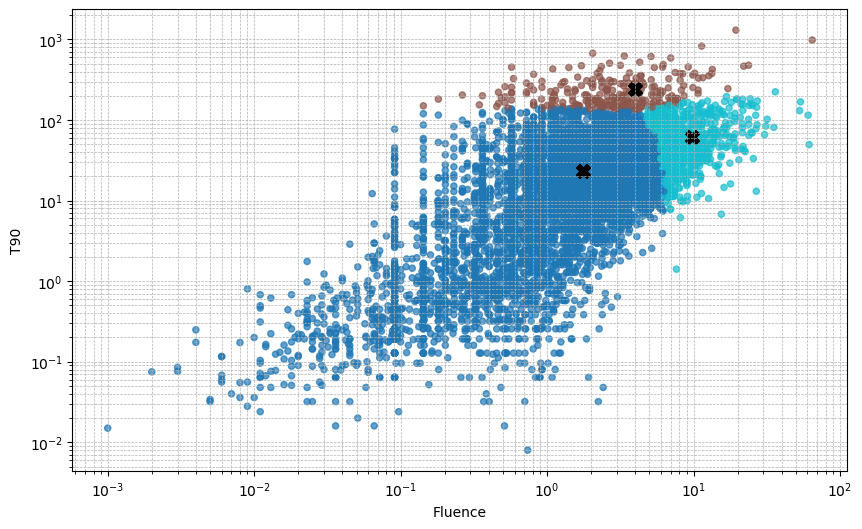

In [16]:
clKM.fit(data_scaled)
centers = clKM.cluster_centers_ 
labels = clKM.labels_ 


plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.scatter(scaler.inverse_transform(centers)[:, 0], scaler.inverse_transform(centers)[:, 1], c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Fluence')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [22]:
clMS = MeanShift(bandwidth=1.0)
clMS.fit(data_scaled)

MeanShift(bandwidth=1.0)

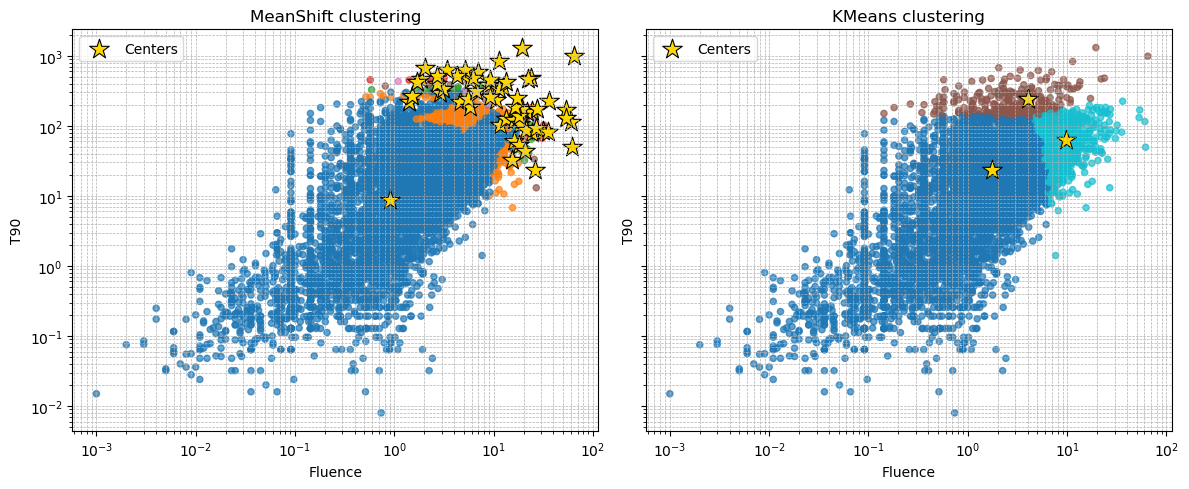

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=clMS.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Fluence')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Fluence')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = scaler.inverse_transform(clKM.cluster_centers_)
centersMS = scaler.inverse_transform(clMS.cluster_centers_)

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**

- We are still very sensible to bandwith. We surely prefer the KMeans alghortihm in this case. We are dealing with some sparse data and KDE isn't the best prescription.

- If, looking to MeanShift, we used the outliers interpretation we would have done wrong.